# Time-dependent constraints

Every constraint we have used so far is *static*: it is fixed when the optimiser is constructed and applies unchanged to every optimisation. Under cross-validation, however, each fold is a separate optimisation over a different slice of time — and sometimes the constraint itself should change with time: a de-leveraging schedule that tightens position caps, a turnover budget relative to the previous rebalance, bounds that react to the volatility regime of the training window.

`TimeDependent` expresses exactly this. It wraps *either* a vector of per-fold values (a **schedule**) *or* a function of the fold's `TimeDependentContext` (a **callable**), and is stored *directly in the optimiser field it varies* — `JuMPOptimiser(; wb = TimeDependent([...]))`. The field's position names what varies, so a field holds either a static value or a schedule, never both. This gives three ways to specify any input typed `TD_Option`:

 1. **Static** — set the field itself; the same value applies to every fold.
 2. **Schedule-based** — `TimeDependent([v₁, …, vₙ])`; entry `i` is the complete field value for fold `i` of the consuming scheme's `split` enumeration.
 3. **Callable** — `TimeDependent(f)`; `f(ctx)` computes the value per fold on the fly. `f` can be a bare function or a `TimeDependentCallable` functor struct.

Two rules govern the behaviour:

  - **Enumeration-order indexing, no hidden ranking**: entry `i` maps to fold `i` of `split(cv, rd)` — the machinery never re-orders folds behind your back. Walk-forward and (unshuffled) KFold enumerate chronologically, so there "fold time" is calendar time; for schemes whose enumeration is not a timeline it is *your* job to key entries off the fold's indices, which the context provides.
  - **Inert outside fold loops**: a plain `optimise` call has no folds, so the schedule simply does not participate — the affected fields run at their static defaults.

In this example we run the same portfolio problem under each cross-validation scheme — `IndexWalkForward`, `KFold`, `CombinatorialCrossValidation` and `MultipleRandomised` — and compare how the three methods behave in each.

In [1]:
using PortfolioOptimisers, PrettyTables
# Format for pretty tables.
resfmt = (v, i, j) -> begin
    if j == 1
        return v
    else
        return isa(v, Number) ? "$(round(v*100, digits=2)) %" : v
    end
end;

## 1. Setting up

We use three years of daily data, a `MeanRisk` minimum-variance optimiser, and a short Clarabel fallback chain. The constraint we vary throughout is the per-asset weight cap (the `wb` field), because its effect is easy to read straight off the optimal weights.

In [2]:
using CSV, TimeSeries, DataFrames, Clarabel, Statistics, StableRNGs

X = TimeArray(CSV.File(joinpath(@__DIR__, "..", "SP500.csv.gz")); timestamp = :Date)[(end - 252 * 3):end]

# Compute the returns.
rd = prices_to_returns(X)

slv = [Solver(; name = :clarabel1, solver = Clarabel.Optimizer,
              settings = Dict("verbose" => false),
              check_sol = (; allow_local = true, allow_almost = true)),
       Solver(; name = :clarabel2, solver = Clarabel.Optimizer,
              settings = Dict("verbose" => false, "max_step_fraction" => 0.9),
              check_sol = (; allow_local = true, allow_almost = true))];

# Static baseline: an uncapped minimum-variance optimiser.
mr_static = MeanRisk(; opt = JuMPOptimiser(; slv = slv))

# A helper that reads the largest weight of each fold's solution.
max_weights(pred) = [maximum(p.res.w) for p in pred.pred];

## 2. The three methods

### 2.1 Static

Nothing new here — a fixed cap of 20 % is just the `wb` field:

In [3]:
mr_capped = MeanRisk(;
                     opt = JuMPOptimiser(; slv = slv,
                                         wb = WeightBounds(; lb = 0.0, ub = 0.2)))

MeanRisk
  opt ┼ JuMPOptimiser
      │        pe ┼ EmpiricalPrior
      │           │        ce ┼ PortfolioOptimisersCovariance
      │           │           │   ce ┼ Covariance
      │           │           │      │    me ┼ SimpleExpectedReturns
      │           │           │      │       │   w ┴ nothing
      │           │           │      │    ce ┼ GeneralCovariance
      │           │           │      │       │   ce ┼ SimpleCovariance: SimpleCovariance(true)
      │           │           │      │       │    w ┴ nothing
      │           │           │      │   alg ┴ FullMoment()
      │           │           │   mp ┼ MatrixProcessing
      │           │           │      │     pdm ┼ Posdef
      │           │           │      │         │      alg ┼ UnionAll: NearestCorrelationMatrix.Newton
      │           │           │      │         │   kwargs ┴ @NamedTuple{}: NamedTuple()
      │           │           │      │      dn ┼ nothing
      │           │           │      │      dt ┼ no

### 2.2 Schedule-based

A schedule is a vector of per-fold values; the field it sits in says what it varies, so there is nothing else to name — the same `Threshold` schedule means "long threshold" in `lt` and "short threshold" in `st`.

The schedule below is a de-leveraging plan: the cap tightens as we walk forward through time. We size it later, once we know how many folds the consuming cross-validation scheme produces — **a schedule must have exactly one entry per fold**, which is validated as soon as the scheme is split, before any fold runs.

In [4]:
function deleverage(n, bind = :outermost)
    return TimeDependent([WeightBounds(; lb = 0.0,
                                       ub = 0.35 - 0.15 * (i - 1) / max(n - 1, 1))
                          for i in 1:n], bind)
end;

### 2.3 Callable

A callable computes the value when the fold runs. It receives a `TimeDependentContext` carrying the fold's enumeration index `i`, the fold count `n`, the (possibly asset-viewed) returns data `rd`, the scheme's fold index vectors, and — only when previous weights are threaded — `w_prev`.

This one reproduces the same de-leveraging plan from the rank alone, so we can check that schedules and callables are two spellings of the same thing:

In [5]:
deleverage_fn = TimeDependent(ctx -> WeightBounds(; lb = 0.0,
                                                  ub = 0.35 -
                                                       0.15 * (ctx.i - 1) /
                                                       max(ctx.n - 1, 1)));

And this one is genuinely dynamic — it reads the volatility of the fold's training window and tightens the cap in turbulent regimes. Note that it indexes `ctx.train_idx` with `ctx.i`; because `i` is the fold's position in the scheme's own enumeration, `ctx.train_idx[ctx.i]`/`ctx.test_idx[ctx.i]` are always the fold's *own* windows, under every scheme.

In [6]:
function vol_cap(ctx)
    Xtr = ctx.rd.X[ctx.train_idx[ctx.i], :]
    vol = std(Xtr * fill(1 / size(Xtr, 2), size(Xtr, 2))) * sqrt(252)
    # 35 % cap in calm regimes, tightening towards 15 % as annualised volatility rises.
    return WeightBounds(; lb = 0.0, ub = clamp(0.35 - vol, 0.15, 0.35))
end
vol_cap_td = TimeDependent(vol_cap);

Callables need not be bare functions. A struct subtyping `TimeDependentCallable` whose functor takes the context does the same job with two advantages: its parameters are inspectable data, and — being a type — a `needs_previous_weights` method can declare a previous-weights requirement directly, without the `PreviousWeightsFunction` wrapper.

Here is the de-leveraging plan once more, as a reusable parameterised type:

In [7]:
struct DeleverageCap <: PortfolioOptimisers.TimeDependentCallable
    hi::Float64
    lo::Float64
end
function (c::DeleverageCap)(ctx::TimeDependentContext)
    return WeightBounds(; lb = 0.0,
                        ub = c.hi - (c.hi - c.lo) * (ctx.i - 1) / max(ctx.n - 1, 1))
end
deleverage_struct = TimeDependent(DeleverageCap(0.35, 0.2))

TimeDependent
   val ┼ Main.var"##534".DeleverageCap
       │   hi ┼ Float64: 0.35
       │   lo ┴ Float64: 0.2
  bind ┴ Symbol: :outermost


### 2.4 Validation happens as early as possible

Because the schedule lives in the field itself, a wrong target is an ordinary keyword error — there is no symbol to typo and no way to give a field both a static value and a schedule. What remains is entry validity: every schedule entry is test-substituted through the constructor, so a type-incompatible entry fails immediately:

In [8]:
try
    JuMPOptimiser(; slv = slv, card = TimeDependent([Threshold(; val = 0.01)]))
catch err
    err
end

TypeError(Symbol("keyword argument"), :card, Union{Nothing, var"#s2376", var"#s843"} where {var"#s843"<:Integer, var"#s2376"<:TimeDependent}, Threshold
  val ┴ Float64: 0.01
)

In [9]:
try
    JuMPOptimiser(; slv = slv, card = TimeDependent([0]))
catch err
    err
end

DomainError("0 < card must hold. Got\ncard => 0", "")

### 2.5 Inert outside fold loops

A fold-less `optimise` has no time axis, so the schedule does not participate — the optimiser behaves exactly like the static baseline (the field runs at its static default):

In [10]:
mr_sched = MeanRisk(; opt = JuMPOptimiser(; slv = slv, wb = deleverage(4)))
res_sched = optimise(mr_sched, rd)
res_static = optimise(mr_static, rd)
isapprox(res_sched.w, res_static.w)

true

## 3. Walk-forward

Walk-forward is the natural home of time-dependent constraints: folds are consecutive rebalances, so "fold time" *is* calendar time. We train on one year and test on the following quarter.

In [11]:
wf = IndexWalkForward(252, 63)
n_wf = n_splits(wf, rd)

8

The schedule needs one entry per fold, so we size it with `n_splits`. All three estimators run through the same `cross_val_predict` call — the fold loop resolves any schedule into an ordinary static optimiser before each solve.

In [12]:
mr_wf_sched = MeanRisk(; opt = JuMPOptimiser(; slv = slv, wb = deleverage(n_wf)))
mr_wf_fn = MeanRisk(; opt = JuMPOptimiser(; slv = slv, wb = deleverage_fn))
mr_wf_vol = MeanRisk(; opt = JuMPOptimiser(; slv = slv, wb = vol_cap_td))

pred_wf_static = cross_val_predict(mr_static, rd, wf)
pred_wf_sched = cross_val_predict(mr_wf_sched, rd, wf)
pred_wf_fn = cross_val_predict(mr_wf_fn, rd, wf)
pred_wf_vol = cross_val_predict(mr_wf_vol, rd, wf)

pretty_table(DataFrame(:fold => 1:n_wf, :static => max_weights(pred_wf_static),
                       :schedule => max_weights(pred_wf_sched),
                       :callable => max_weights(pred_wf_fn),
                       :vol_callable => max_weights(pred_wf_vol)); formatters = [resfmt])

┌───────┬─────────┬──────────┬──────────┬──────────────┐
│  fold │  static │ schedule │ callable │ vol_callable │
│ Int64 │ Float64 │  Float64 │  Float64 │      Float64 │
├───────┼─────────┼──────────┼──────────┼──────────────┤
│     1 │ 39.87 % │   35.0 % │   35.0 % │       15.0 % │
│     2 │ 28.46 % │  28.47 % │  28.47 % │       15.0 % │
│     3 │ 26.02 % │  26.02 % │  26.02 % │      20.37 % │
│     4 │ 22.98 % │  22.99 % │  22.99 % │      21.29 % │
│     5 │ 14.99 % │  14.99 % │  14.99 % │      14.99 % │
│     6 │  16.5 % │   16.5 % │   16.5 % │       16.5 % │
│     7 │  30.3 % │  22.14 % │  22.14 % │      18.01 % │
│     8 │ 33.48 % │   20.0 % │   20.0 % │      16.83 % │
└───────┴─────────┴──────────┴──────────┴──────────────┘


The static column is free to concentrate; the schedule column respects the tightening cap fold by fold; the rank-based callable matches the schedule exactly (same rule, different spelling); and the volatility callable moves with the regime instead of the calendar.

The struct form is a third spelling of the same rule — its fold weights are identical to the function form's:

In [13]:
pred_wf_struct = cross_val_predict(MeanRisk(;
                                            opt = JuMPOptimiser(; slv = slv,
                                                                wb = deleverage_struct)),
                                   rd, wf)
all(isapprox(a.res.w, b.res.w) for (a, b) in zip(pred_wf_struct.pred, pred_wf_fn.pred))

true

The composition plot makes the de-leveraging visible — later folds are forced to spread weight across more assets:

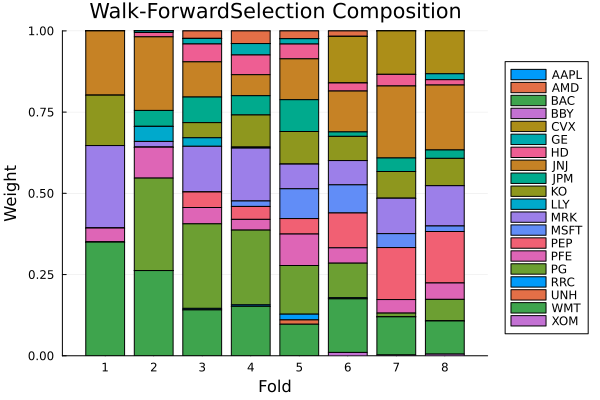

In [14]:
using StatsPlots, GraphRecipes
plot_composition(pred_wf_sched)

### 3.1 Previous weights

Schedules and callables are resolved *before* the previous-weights factory pass, so a per-fold turnover constraint swapped in by a schedule still receives the previous fold's weights. A callable can also read the previous weights directly, but because a bare function cannot be inspected, it must declare the requirement by wrapping itself in `PreviousWeightsFunction` — this is what flips `needs_previous_weights` and forces the fold loop to run sequentially (an *undeclared* callable would see `w_prev === nothing`).

Here each asset may move at most 2 percentage points per rebalance relative to its previous weight; fold 1 has no previous weights, so returning `nothing` leaves the turnover constraint off:

In [15]:
tn_budget = TimeDependent(PreviousWeightsFunction(ctx -> if isnothing(ctx.w_prev)
                                                      nothing
                                                  else
                                                      Turnover(; w = ctx.w_prev, val = 0.02)
                                                  end))
mr_wf_tn = MeanRisk(; opt = JuMPOptimiser(; slv = slv, tn = tn_budget))
pred_wf_tn = cross_val_predict(mr_wf_tn, rd, wf)

# One-norm distance between consecutive folds, with and without the budget.
function l1turnover(pred)
    return [sum(abs, pred.pred[i].res.w - pred.pred[i - 1].res.w)
            for i in 2:length(pred.pred)]
end
pretty_table(DataFrame(:rebalance => 2:n_wf, :static => l1turnover(pred_wf_static),
                       :budgeted => l1turnover(pred_wf_tn)); formatters = [resfmt])

┌ Info: Running cross-validation sequentially because the optimiser must use the previous optimisation's weights (needs_previous_weights(opt) == true). This is because somewhere within the optimisation estimator is contained at least one of the following:
│ 	- Turnover and/or TurnoverEstimator,
│ 	- WeightsTracking,
│ 	- TurnoverRiskMeasure,
│ 	- custom constraints which use asset weights,
│ 	- custom objective penalties which use asset weights,
│ 	- a time-dependent constraint whose entries need previous weights (e.g. a PreviousWeightsFunction).
└ To enable parallel processing please either mark the weights as fixed or remove the offending component(s). Time-dependent constraints alone do not force sequential processing.
┌───────────┬──────────┬──────────┐
│ rebalance │   static │ budgeted │
│     Int64 │  Float64 │  Float64 │
├───────────┼──────────┼──────────┤
│         2 │ 102.85 % │   12.0 % │
│         3 │  65.75 % │  17.86 % │
│         4 │  28.51 % │  21.12 % │
│         5 │  5

Note the informational message: it is the previous-weights requirement that forces sequential execution, not time dependence itself. Schedules and undeclared callables keep the fold loop fully parallel because entry `i` is known upfront.

## 4. KFold

KFold's folds are also time-ordered slices (shuffling is rejected for optimisation cross-validation), so schedules carry over unchanged — with one difference in interpretation: fold `i` *tests* on the `i`-th slice while training on the rest, so a schedule reads "the constraint in force while slice `i` is out of sample". Everything stays parallel.

In [16]:
kfold = KFold(; n = 4)
mr_kf_sched = MeanRisk(; opt = JuMPOptimiser(; slv = slv, wb = deleverage(4)))
pred_kf_static = cross_val_predict(mr_static, rd, kfold)
pred_kf_sched = cross_val_predict(mr_kf_sched, rd, kfold)
pred_kf_fn = cross_val_predict(MeanRisk(;
                                        opt = JuMPOptimiser(; slv = slv,
                                                            wb = deleverage_fn)), rd, kfold)

pretty_table(DataFrame(:fold => 1:4, :static => max_weights(pred_kf_static),
                       :schedule => max_weights(pred_kf_sched),
                       :callable => max_weights(pred_kf_fn)); formatters = [resfmt])

┌───────┬─────────┬──────────┬──────────┐
│  fold │  static │ schedule │ callable │
│ Int64 │ Float64 │  Float64 │  Float64 │
├───────┼─────────┼──────────┼──────────┤
│     1 │ 25.76 % │  25.78 % │  25.78 % │
│     2 │ 32.87 % │   30.0 % │   30.0 % │
│     3 │ 27.41 % │   25.0 % │   25.0 % │
│     4 │  35.8 % │   20.0 % │   20.0 % │
└───────┴─────────┴──────────┴──────────┘


A mis-sized schedule fails at `split` time — before a single fold is solved — with the fold count the scheme actually produced:

In [17]:
try
    cross_val_predict(MeanRisk(; opt = JuMPOptimiser(; slv = slv, wb = deleverage(7))), rd,
                      kfold)
catch err
    err
end

DimensionMismatch("time-dependent entries for wb (7) must equal the number of folds (4)")

## 5. Combinatorial

Under `CombinatorialCrossValidation` a *fold* is a train/test split, and each split's test set is a union of several disjoint time groups. Splits are enumerated combinatorially, so the enumeration is *not* a timeline — and the machinery deliberately does not invent one: any single "position in time" for a split whose test set is a union of disjoint groups would be an arbitrary hidden policy. Entry `i` simply belongs to split `i` of `split(ccv, rd)`, which you can inspect; to key a constraint to time here, prefer a callable that reads its own windows (`ctx.train_idx[ctx.i]`/`ctx.test_idx[ctx.i]`) and derives whatever ordering your problem calls for.

In [18]:
ccv = CombinatorialCrossValidation(; n_folds = 4, n_test_folds = 2)
n_ccv = n_splits(ccv)

6

With 4 groups choose 2 test groups we get 6 splits, so the schedule needs 6 entries — one per split, in `split(ccv, rd)`'s enumeration order. Because a split spans several time groups, "the constraint in force for this split" is inherently coarser in meaning than under walk-forward; the schedule below is kept to show the mechanics (entry `i` caps split `i`), and a genuinely time-keyed policy is better expressed as a callable deriving its value from its own windows.

In [19]:
mr_cc_sched = MeanRisk(; opt = JuMPOptimiser(; slv = slv, wb = deleverage(n_ccv)))
pred_cc_static = cross_val_predict(mr_static, rd, ccv)
pred_cc_sched = cross_val_predict(mr_cc_sched, rd, ccv)

# Largest weight across each path's folds; paths recombine the splits, so the cap shows
# up path by path.
pretty_table(DataFrame(:path => 1:length(pred_cc_sched.pred),
                       :static => [maximum(maximum(p.res.w) for p in path.pred)
                                   for path in pred_cc_static.pred],
                       :schedule => [maximum(maximum(p.res.w) for p in path.pred)
                                     for path in pred_cc_sched.pred]);
             formatters = [resfmt])

┌───────┬─────────┬──────────┐
│  path │  static │ schedule │
│ Int64 │ Float64 │  Float64 │
├───────┼─────────┼──────────┤
│     1 │ 35.74 % │   35.0 % │
│     2 │  37.0 % │  28.64 % │
│     3 │ 37.23 % │   23.0 % │
└───────┴─────────┴──────────┘


## 6. MultipleRandomised

`MultipleRandomised` crosses random *asset subsets* with a walk-forward over time, producing one path per subset. Two things happen to a schedule here:

  - `ctx.i` is the fold's position in the path's enumeration; predictions are re-sorted by test window *afterwards, for reporting only* — output order never influences which entry a fold received.
  - Each path sees a different asset universe: the optimiser is *viewed* down to the subset before the schedule is resolved, so schedule entries are sub-selected along with everything else, and callables see the viewed universe through `ctx.rd` (its `nx` are the subset's names).

A universe-aware callable is the natural fit — here the cap adapts to however many assets the path drew, allowing at most twice the equal weight:

In [20]:
mrand = MultipleRandomised(IndexWalkForward(252, 63); subset_size = 15, n_subsets = 3,
                           rng = StableRNG(987654321), seed = 42)
universe_cap = TimeDependent(ctx -> WeightBounds(; lb = 0.0, ub = 2.0 / length(ctx.rd.nx)))
mr_mr_fn = MeanRisk(; opt = JuMPOptimiser(; slv = slv, wb = universe_cap))
pred_mr_static = cross_val_predict(mr_static, rd, mrand)
pred_mr_fn = cross_val_predict(mr_mr_fn, rd, mrand)

pretty_table(DataFrame(:path => 1:length(pred_mr_fn.pred),
                       :static => [maximum(maximum(p.res.w) for p in path.pred)
                                   for path in pred_mr_static.pred],
                       :callable => [maximum(maximum(p.res.w) for p in path.pred)
                                     for path in pred_mr_fn.pred],
                       :cap => fill(2.0 / 15, length(pred_mr_fn.pred)));
             formatters = [resfmt])

┌───────┬─────────┬──────────┬─────────┐
│  path │  static │ callable │     cap │
│ Int64 │ Float64 │  Float64 │ Float64 │
├───────┼─────────┼──────────┼─────────┤
│     1 │ 42.14 % │  13.33 % │ 13.33 % │
│     2 │  40.0 % │  13.33 % │ 13.33 % │
│     3 │ 39.87 % │  13.33 % │ 13.33 % │
└───────┴─────────┴──────────┴─────────┘


Schedules work here too — sized to the folds *per path* (the walk-forward fold count), shared across paths:

In [21]:
n_mr = n_splits(IndexWalkForward(252, 63), rd)
mr_mr_sched = MeanRisk(; opt = JuMPOptimiser(; slv = slv, wb = deleverage(n_mr)))
pred_mr_sched = cross_val_predict(mr_mr_sched, rd, mrand)
length(pred_mr_sched.pred)

3

## 7. Nesting fold loops: who consumes the schedule?

Meta-optimisers like `Stacking` and `NestedClustered` run a cross-validation of their *own* to estimate inner out-of-sample returns. That means a schedule inside a meta can sit under **two** fold loops — the meta's inner one and, when the meta itself is backtested with `cross_val_predict`, an outer one. Which one consumes the schedule is chosen by its `bind`: the default `:outermost` means **the outermost fold loop wins**, while `:nearest` (§7.5) hands the schedule to the nearest enclosing loop instead. Either way the entries must be sized for whichever loop actually consumes them.

### 7.1 Outer CV, no inner CV

This is everything we have done so far: the backtest's fold loop resolves the schedule and each fold solves an ordinary static optimiser.

### 7.2 No outer CV, inner CV

Used standalone, a meta's inner cross-validation is the outermost (and only) fold loop, so it consumes the schedules of its inner estimators — sized to the *inner* scheme's folds. The meta's fold-less full-window inner solves run at the fields' static defaults, exactly like a plain `optimise`.

Here one of the stacked optimisers de-leverages across the inner `KFold(4)` folds used to build the out-of-sample returns fed to the outer optimiser:

In [22]:
st_inner = Stacking(;
                    opti = [MeanRisk(;
                                     opt = JuMPOptimiser(; slv = slv, wb = deleverage(4))),
                            mr_static], opto = mr_static,
                    cv = OptimisationCrossValidation(; cv = KFold(; n = 4)))
res_st_inner = optimise(st_inner, rd)
maximum(res_st_inner.w)

0.27273603332773155

The same estimator with a mis-sized schedule fails at the *inner* split:

In [23]:
try
    optimise(Stacking(;
                      opti = [MeanRisk(;
                                       opt = JuMPOptimiser(; slv = slv, wb = deleverage(7))),
                              mr_static], opto = mr_static,
                      cv = OptimisationCrossValidation(; cv = KFold(; n = 4))), rd)
catch err
    err
end

DimensionMismatch("time-dependent entries for wb (7) must equal the number of folds (4)")

### 7.3 Outer CV + inner CV

Backtesting that same meta puts an outer fold loop on top. Now the *outer* loop resolves every schedule — the meta's own fields and its inner estimators' — against the outer folds *before* the meta ever runs, so the inner `KFold(4)` only ever sees static estimators. The schedule therefore must be sized to the **outer** fold count, even though it lives next to an inner `KFold(4)`:

In [24]:
st_nested = Stacking(;
                     opti = [MeanRisk(;
                                      opt = JuMPOptimiser(; slv = slv,
                                                          wb = deleverage(n_wf))),
                             mr_static], opto = mr_static,
                     cv = OptimisationCrossValidation(; cv = KFold(; n = 4)))
pred_st_nested = cross_val_predict(st_nested, rd, wf)
pretty_table(DataFrame(:fold => 1:n_wf, :stacked => max_weights(pred_st_nested));
             formatters = [resfmt])

┌───────┬─────────┐
│  fold │ stacked │
│ Int64 │ Float64 │
├───────┼─────────┤
│     1 │  35.0 % │
│     2 │ 28.47 % │
│     3 │ 26.02 % │
│     4 │ 22.99 % │
│     5 │ 14.99 % │
│     6 │  16.5 % │
│     7 │ 23.72 % │
│     8 │ 22.47 % │
└───────┴─────────┘


And the inner-sized schedule from §7.2 now fails at the *outer* split — same estimator, different consumer:

In [25]:
try
    cross_val_predict(st_inner, rd, wf)
catch err
    err
end

DimensionMismatch("time-dependent entries for wb (4) must equal the number of folds (8)")

### 7.4 A hyperparameter-tuning pass over schedules

Because a schedule is just a field value, it is tunable like any other hyperparameter: `GridSearchCrossValidation` sets each candidate into the field through the estimator's validated constructor and scores it with its own cross-validation. Here we let the data pick between staying uncapped, the de-leveraging plan, and a gentler variant:

In [26]:
function gentler(n)
    return TimeDependent([WeightBounds(; lb = 0.0,
                                       ub = 0.45 - 0.1 * (i - 1) / max(n - 1, 1))
                          for i in 1:n])
end;
candidates = ["opt.wb" => [WeightBounds(), deleverage(n_wf), gentler(n_wf)]]
gs = GridSearchCrossValidation(candidates; cv = wf)
gs_res = search_cross_validation(mr_static, gs, rd)
gs_res.idx

1

The winning candidate (`gs_res.val_grid[gs_res.idx]`) is whichever schedule scored best out of sample — the tuning pass consumes each candidate's entries through the search's own fold loop, so every candidate must be sized to `n_splits(gs.cv, rd)`.

### 7.5 Binding to the inner loop with `:nearest`

Sometimes you want the opposite of §7.3: a schedule that belongs to a meta's *inner* cross-validation and should keep being consumed there even when the meta is backtested under an outer loop — an inner estimator whose regularisation follows the inner `KFold(4)`, say, regardless of the outer horizon. Pass `bind = :nearest` (here through the `deleverage` helper's second argument). The outer loop then skips it and the inner loop resolves it, so it is sized to the **inner** folds even under an outer backtest:

In [27]:
st_bind_near = Stacking(;
                        opti = [MeanRisk(;
                                         opt = JuMPOptimiser(; slv = slv,
                                                             wb = deleverage(4, :nearest))),
                                mr_static], opto = mr_static,
                        cv = OptimisationCrossValidation(; cv = KFold(; n = 4)))
pred_bind_near = cross_val_predict(st_bind_near, rd, wf)
pretty_table(DataFrame(:fold => 1:n_wf, :nearest => max_weights(pred_bind_near));
             formatters = [resfmt])

┌───────┬─────────┐
│  fold │ nearest │
│ Int64 │ Float64 │
├───────┼─────────┤
│     1 │ 39.87 % │
│     2 │ 28.46 % │
│     3 │ 26.02 % │
│     4 │ 22.98 % │
│     5 │ 14.99 % │
│     6 │  16.5 % │
│     7 │  30.3 % │
│     8 │ 33.48 % │
└───────┴─────────┘


The size-4 schedule that failed at the *outer* split in §7.3 now succeeds, because `:nearest` routes it past the outer loop to the inner `KFold(4)`. The two binds compose freely: a meta's own `wb` can be `:outermost` (sized to the backtest) while an inner estimator's schedule is `:nearest` (sized to the inner scheme), each validated at its own split.

### 7.6 Per-fold *vectors* of constraints

An input that already accepts a vector of constraints varies over folds by holding a per-fold *vector of vectors* — entry `i` is fold `i`'s whole constraint vector. Here the linear-constraint input `lcse` tightens from one cap in early folds to two in later ones:

In [28]:
sets = AssetSets(; dict = Dict("nx" => rd.nx))
cap_a = LinearConstraintEstimator(; val = "$(rd.nx[1]) <= 0.5")
cap_b = LinearConstraintEstimator(; val = "$(rd.nx[2]) <= 0.5")
lcse_sched = TimeDependent([i <= n_wf ÷ 2 ? [cap_a] : [cap_a, cap_b] for i in 1:n_wf])
mr_lcse = MeanRisk(; opt = JuMPOptimiser(; slv = slv, sets = sets, lcse = lcse_sched))
pred_lcse = cross_val_predict(mr_lcse, rd, wf)
pretty_table(DataFrame(:fold => 1:n_wf, :vector_schedule => max_weights(pred_lcse));
             formatters = [resfmt])

┌───────┬─────────────────┐
│  fold │ vector_schedule │
│ Int64 │         Float64 │
├───────┼─────────────────┤
│     1 │         39.87 % │
│     2 │         28.44 % │
│     3 │         26.03 % │
│     4 │         22.99 % │
│     5 │         14.99 % │
│     6 │          16.5 % │
│     7 │          30.3 % │
│     8 │         33.46 % │
└───────┴─────────────────┘


There is no separate "vector of schedules": to vary only *some* entries of a constraint vector, build the fold's vector inside a callable — `TimeDependent(ctx -> [dynamic(ctx), a_static_constraint])` — which also keeps the shared static parts in one place.

## 8. Summary

| Method | Spelling | Sized/validated | Parallel? | Best for |
|---|---|---|---|---|
| Static | the field itself | at construction | yes | constraints that do not change |
| Schedule | `field = TimeDependent([v₁, …, vₙ])` | each entry test-substituted at construction; length vs fold count at `split` time | yes | known calendars: de-leveraging plans, phased mandates, regime dates fixed in advance |
| Callable | `field = TimeDependent(f)` — a function, or a `TimeDependentCallable` struct that can declare previous-weights needs as a trait | output validated by the host constructor at each fold | yes, unless previous weights are declared (`PreviousWeightsFunction` wrapper or the struct's trait) | values computed from the fold: volatility regimes, universe size, previous weights |

Across schemes, the entry index always means the same thing — fold `i` of the consuming scheme's `split` enumeration, with `ctx.train_idx[ctx.i]`/`ctx.test_idx[ctx.i]` as the fold's own windows — and whatever the spelling, each fold ends up solving an ordinary static optimiser: the schedule is resolved through the host's validated constructor, so nothing downstream of the fold loop knows time dependence exists. For an input that accepts a vector of constraints, a schedule is a per-fold vector of vectors (§7.6). Meta-optimisers (`NestedClustered`, `Stacking`, `SubsetResampling`) accept schedules in their own `wb`/`fees` and forward the resolution into their inner estimators like any other wrapper. Which fold loop consumes a schedule is its `bind`: the default `:outermost` means an outer fold loop over a meta resolves an inner schedule against the outer folds (standalone, the meta's inner cross-validation consumes it instead), while `:nearest` (§7.5) keeps a meta's inner schedule bound to the inner cross-validation even under an outer backtest.

---

*This notebook was generated using [Literate.jl](https://github.com/fredrikekre/Literate.jl).*